Import Libraries

In [34]:
import yfinance as yf
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout, LayerNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from scikeras.wrappers import KerasRegressor
from keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam

Getting Data

In [35]:
ticker_symbol = "TSLA"
start_date = "2021-01-01"
end_date = "2022-12-31"

# Download historical data
tesla_data = yf.download(ticker_symbol, start=start_date, end=end_date)

# Display the historical data
tesla_data.head()

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-01-04,239.820007,248.163330,239.063339,243.256668,243.256668,145914600
2021-01-05,241.220001,246.946671,239.733337,245.036667,245.036667,96735600
2021-01-06,252.830002,258.000000,249.699997,251.993332,251.993332,134100000
2021-01-07,259.209991,272.329987,258.399994,272.013336,272.013336,154496700
2021-01-08,285.333344,294.829987,279.463318,293.339996,293.339996,225166500


In [36]:
tesla_data.drop(columns=["Close"],inplace=True)
tesla_data

,Open,High,Low,Adj Close,Volume
Date,,,,,
2021-01-04,239.820007,248.163330,239.063339,243.256668,145914600
2021-01-05,241.220001,246.946671,239.733337,245.036667,96735600
2021-01-06,252.830002,258.000000,249.699997,251.993332,134100000
2021-01-07,259.209991,272.329987,258.399994,272.013336,154496700
2021-01-08,285.333344,294.829987,279.463318,293.339996,225166500
...,...,...,...,...,...
2022-12-23,126.370003,128.619995,121.019997,123.150002,166989700
2022-12-27,117.500000,119.669998,108.760002,109.099998,208643400
2022-12-28,110.349998,116.269997,108.239998,112.709999,221070500


In [37]:
tesla_data.iloc[int(len(tesla_data)*0.8):]

,Open,High,Low,Adj Close,Volume
Date,,,,,
2022-08-09,290.293335,292.396667,279.353333,283.333344,86244600
2022-08-10,297.066681,297.510010,283.369995,294.356659,94918800
2022-08-11,296.513336,298.236664,285.833344,286.630005,70155000
2022-08-12,289.416656,300.160004,285.033325,300.029999,79657200
2022-08-15,301.786682,313.133331,301.230011,309.320007,89359200
...,...,...,...,...,...
2022-12-23,126.370003,128.619995,121.019997,123.150002,166989700
2022-12-27,117.500000,119.669998,108.760002,109.099998,208643400
2022-12-28,110.349998,116.269997,108.239998,112.709999,221070500


In [38]:
tesla_data.shape


(503, 5)

In [39]:
tesla_data.isna().sum()

Open         0
High         0
Low          0
Adj Close    0
Volume       0
dtype: int64

# Normalizing Data
- Stabilizing Training -> Prevents the gradient becoming too small or too large
- Equalizing Scale -> Ensuring all features contribute equally
- Improved Convergence -> Neural Network tend to converge faster when the data is centered arround zero.
- Avoiding Vanishing / Exploding Gradient

In [40]:
data_y = tesla_data["Adj Close"]
data_X = tesla_data.drop(columns=["Adj Close"])

data_y_reshaped = data_y.values.reshape(-1, 1)

scaler_y = MinMaxScaler(feature_range=(0,1))
scaled_y = scaler_y.fit_transform(data_y_reshaped)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_X = scaler.fit_transform(data_X)

df_data_X = pd.DataFrame(scaled_X, columns=data_X.columns)
df_data_y = pd.DataFrame(scaled_y, columns=["Adj Close"])

scaled_data = pd.concat([df_data_X, df_data_y], axis=1)

scaled_data

,Open,High,Low,Volume,Adj Close
0,0.429962,0.442259,0.439851,0.487935,0.445896
1,0.434611,0.438179,0.442103,0.281982,0.451812
2,0.473167,0.475243,0.475613,0.438457,0.474934
3,0.494354,0.523293,0.504864,0.523875,0.541474
4,0.581108,0.598739,0.575682,0.819827,0.612357
...,...,...,...,...,...
498,0.053201,0.041411,0.042969,0.576193,0.046698
499,0.023745,0.011401,0.001748,0.750632,0.000000
500,0.000000,0.000000,0.000000,0.802674,0.011999
501,0.033342,0.024478,0.031134,0.806245,0.042277


# Prepearing RNN Data

<img src="/home/arda/Turkcell/RNN/sma_viz.gif" alt="Alt Text">


- Rolling Window Approach -> Capturing Temporal Patterns and Dependencies

In [41]:
time_step = 3
X, y = [], []

for i in range(len(scaled_data) - time_step):
    X.append(scaled_data[i:i + time_step])
    y.append(scaled_data.iloc[i + time_step, 4])

X, y = np.array(X), np.array(y)
y

array([0.54147418, 0.61235748, 0.53610087, 0.57847797, 0.58398426,
       0.57355887, 0.55268607, 0.57306033, 0.57959696, 0.57354781,
       0.5753758 , 0.61322168, 0.61575877, 0.59478627, 0.56295627,
       0.51653541, 0.56780894, 0.60434737, 0.58429444, 0.57908727,
       0.58156898, 0.5939664 , 0.57850008, 0.52904359, 0.53662161,
       0.54156283, 0.51951566, 0.52165383, 0.50972178, 0.50298574,
       0.4289782 , 0.41162851, 0.45946753, 0.39321522, 0.38577017,
       0.43333224, 0.39789058, 0.36106404, 0.32587718, 0.29985265,
       0.26113163, 0.38364301, 0.37752737, 0.41247049, 0.40596714,
       0.42171036, 0.38729905, 0.41491894, 0.36101972, 0.36291419,
       0.3796767 , 0.3709908 , 0.33565991, 0.34687185, 0.32285261,
       0.31463202, 0.34158719, 0.37738334, 0.37053654, 0.40299799,
       0.40362945, 0.38075136, 0.39496572, 0.38745418, 0.4151073 ,
       0.4819579 , 0.4486212 , 0.45595553, 0.45698587, 0.42912224,
       0.43395264, 0.46179411, 0.43472818, 0.44548586, 0.45523

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train.shape

(400, 3, 5)

# Creating RNN Model
<img src="/home/arda/Turkcell/RNN/Screenshot from 2024-01-04 10-34-50.png" alt="Alt text">

- In the traditional neural network, the inputs and the outputs are independent of each other.
- In RNN is dependent on prior elementals within the sequence.
- Recurrent networks also share parameters across each layer of the network. In feedforward networks, there are different weights across each node.
- Whereas RNN shares the same weights within each layer of the network and during gradient descent, the weights and basis are adjusted individually to reduce the loss.
- The middle layer consists of multiple hidden layers, each with its activation functions, weights, and biases. 
- In backpropagation, the model adjusts the parameter by calculating errors from the output to the input layer.
- BPTT sums the error at each time step as RNN shares parameters across each layer. Learn more on RNNs and how they work at What are Recurrent Neural Networks?.


In [67]:
def create_model(units=50, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential()
    model.add(SimpleRNN(units=units, activation="tanh", input_shape=(X_train.shape[1], X_train.shape[2])))  
    #model.add(LayerNormalization())
    #model.add(Dropout(dropout_rate))
    model.add(Dense(units=1, activation="linear"))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")

    return model

<img src="/home/arda/Turkcell/RNN/Screenshot from 2024-01-04 11-28-46.png" alt="Alt text">

- The simple RNN repeating modules have a basic structure with a single tanh layer.
 
- RNN simple structure suffers from short memory, where it struggles to retain previous time step information in larger sequential data.

- The tanh function squashes its input to the range (−1,1), which is centered around zero. This means that the output values are less likely to suffer from the vanishing gradient problem compared to the sigmoid function. The vanishing gradient problem can be a significant issue in the context of learning long-range dependencies in sequences.

- The characteristics of tanh make it well-suited for capturing patterns and dependencies in sequential data. The squashing effect allows the network to learn representations that can vary in strength, and the zero-centered property helps with the stability of the optimization process.

- The Problem of Long Term Dependencies


In [69]:
param_grid = {
    'model__units': [10, 20, 25, 30],
    'model__dropout_rate': [0.15, 0.2],
    'model__learning_rate': [0.001, 0.01, 0.1],  
    'batch_size': [32, 64, 128],
    'epochs': [50, 100, 150],
}

tscv = TimeSeriesSplit(n_splits=5)

keras_wrapped_model = KerasRegressor(model=create_model, verbose=0)

scorer = make_scorer(mean_squared_error, greater_is_better=False)

random_search = RandomizedSearchCV(
    keras_wrapped_model, param_distributions=param_grid, scoring=scorer,  cv=tscv, n_iter=20
)

random_search.fit(X_train, y_train)

print("Best Hyperparameters:", random_search.best_params_) # is it finding best params according to test

Best Hyperparameters: {'model__units': 25, 'model__learning_rate': 0.01, 'model__dropout_rate': 0.2, 'epochs': 150, 'batch_size': 32}


In [70]:
results = random_search.cv_results_

for i in range(len(results['mean_test_score'])):
    params = results['params'][i]
    score = results['mean_test_score'][i]
    print(f"Params: {params} - Score: {score}")

Params: {'model__units': 25, 'model__learning_rate': 0.01, 'model__dropout_rate': 0.2, 'epochs': 100, 'batch_size': 64} - Score: -0.0017804682065558713
Params: {'model__units': 20, 'model__learning_rate': 0.1, 'model__dropout_rate': 0.2, 'epochs': 50, 'batch_size': 64} - Score: -0.005731471809252137
Params: {'model__units': 10, 'model__learning_rate': 0.001, 'model__dropout_rate': 0.2, 'epochs': 50, 'batch_size': 128} - Score: -0.00453974742167565
Params: {'model__units': 30, 'model__learning_rate': 0.001, 'model__dropout_rate': 0.2, 'epochs': 150, 'batch_size': 32} - Score: -0.0024162395358522473
Params: {'model__units': 20, 'model__learning_rate': 0.001, 'model__dropout_rate': 0.15, 'epochs': 50, 'batch_size': 32} - Score: -0.0025037381420531845
Params: {'model__units': 10, 'model__learning_rate': 0.01, 'model__dropout_rate': 0.2, 'epochs': 50, 'batch_size': 32} - Score: -0.0028481712446928906
Params: {'model__units': 25, 'model__learning_rate': 0.1, 'model__dropout_rate': 0.2, 'epoc

In [73]:
best_params = random_search.best_params_

model = create_model(
    units=best_params['model__units'],
    dropout_rate=best_params['model__dropout_rate'],
    learning_rate=best_params['model__learning_rate']
)

model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'])


Epoch 1/150
13/13 [==============================] - 2s 4ms/step - loss: 0.2137
Epoch 2/150
13/13 [==============================] - 0s 4ms/step - loss: 0.0334
Epoch 3/150
13/13 [==============================] - 0s 3ms/step - loss: 0.0087
Epoch 4/150
13/13 [==============================] - 0s 6ms/step - loss: 0.0042
Epoch 5/150
13/13 [==============================] - 0s 5ms/step - loss: 0.0025
Epoch 6/150
13/13 [==============================] - 0s 5ms/step - loss: 0.0020
Epoch 7/150
13/13 [==============================] - 0s 4ms/step - loss: 0.0018
Epoch 8/150
13/13 [==============================] - 0s 4ms/step - loss: 0.0017
Epoch 9/150
13/13 [==============================] - 0s 3ms/step - loss: 0.0016
Epoch 10/150
13/13 [==============================] - 0s 4ms/step - loss: 0.0016
Epoch 11/150
13/13 [==============================] - 0s 4ms/step - loss: 0.0016
Epoch 12/150
13/13 [==============================] - 0s 5ms/step - loss: 0.0016
Epoch 13/150
13/13 [=================

In [74]:
scaled_pred = model.predict(X_test)
print(X_test.shape)

y_pred = scaler_y.inverse_transform(scaled_pred.reshape(-1, 1))
y_true = scaler_y.inverse_transform(y_test.reshape(-1,1))

print(scaled_pred.shape)
print(y_true.shape)

mae = mean_absolute_error(y_true, y_pred)

mse = mean_squared_error(y_true, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_true, y_pred)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R2 Score: {r2}')

4/4 [==============================] - 0s 3ms/step
(100, 3, 5)
(100, 1)
(100, 1)
MAE: 6.774704132080077
MSE: 73.75159523772541
RMSE: 8.587874896487804
R2 Score: 0.9770471659318329


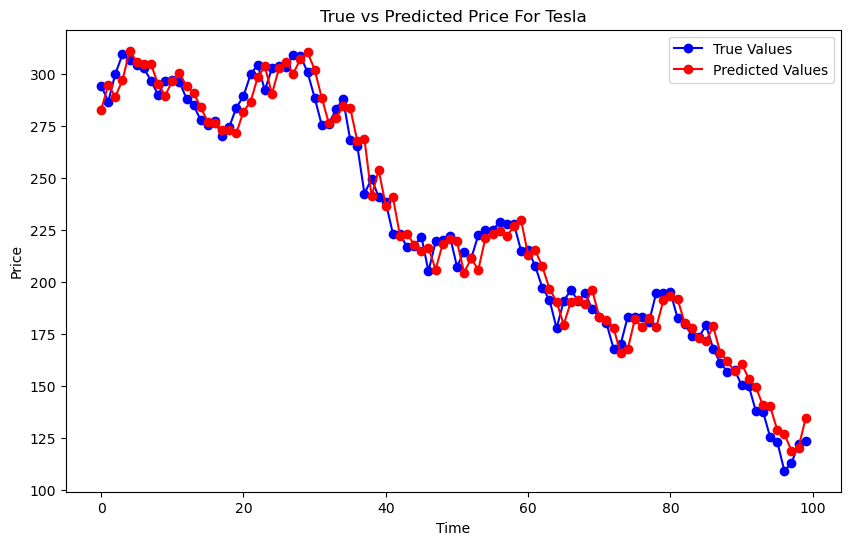

In [75]:
plt.figure(figsize=(10, 6))

plt.plot(y_true, label='True Values', marker='o', linestyle='-', color='blue')

plt.plot(y_pred, label='Predicted Values', marker='o', linestyle='-', color='red')

plt.xlabel('Time')
plt.ylabel('Price')
plt.title('True vs Predicted Price For Tesla')
plt.legend()

plt.show()